In [15]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import statsmodels.formula.api as smf
from empiricaldist import Pmf
from utils import (
    decorate, 
    make_uniform, 
    make_joint, 
    plot_contour, 
    marginal
)

sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 17.1 More Snow?

In [3]:
df = pd.read_csv('./data/2239075.csv', parse_dates=[2])
df.tail(3)

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS,WESD,WT01,WT03,WT04,WT05,WT06,WT08,WT09,WT11,WT16,WT18
19357,USC00190736,"BLUE HILL COOP, MA US",2020-05-09,0.45,0.0,0.0,57,34.0,34.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19358,USC00190736,"BLUE HILL COOP, MA US",2020-05-10,0.00,0.0,0.0,44,31.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19359,USC00190736,"BLUE HILL COOP, MA US",2020-05-11,0.00,0.0,0.0,59,38.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df['YEAR'] = df['DATE'].dt.year
snow = df.groupby('YEAR')['SNOW'].sum()

In [5]:
snow = snow.iloc[1:-1]
len(snow)

52

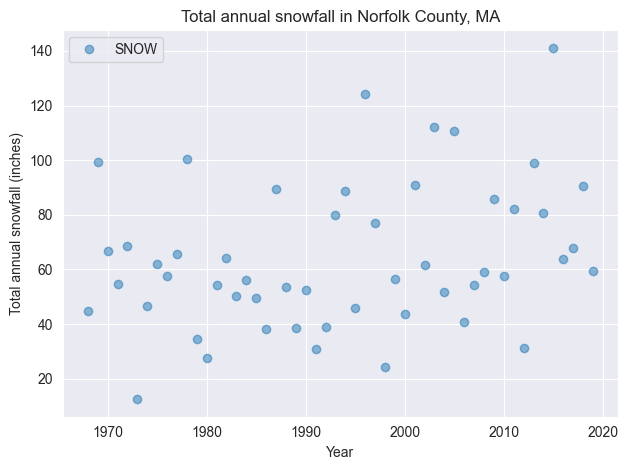

In [6]:
snow.plot(ls='', marker='o', alpha=0.5)

decorate(
    xlabel='Year',
    ylabel='Total annual snowfall (inches)',
    title='Total annual snowfall in Norfolk County, MA'
)

In [7]:
snow.loc[[1978, 1996, 2015]]

YEAR
1978    100.6
1996    124.2
2015    141.1
Name: SNOW, dtype: float64

## 17.2 Regression Model

In [8]:
pmf_snowfall = Pmf.from_seq(snow)
mean, std = pmf_snowfall.mean(), pmf_snowfall.std()
mean, std

(64.19038461538462, 26.28802198439569)

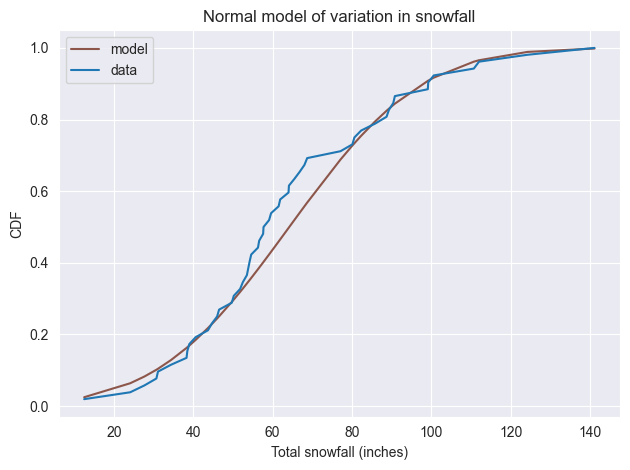

In [11]:
dist = norm(mean, std)
qs = pmf_snowfall.qs
ps = dist.cdf(qs)

plt.plot(qs, ps, color='C5', label='model')
pmf_snowfall.make_cdf().plot(label='data')
decorate(
    xlabel='Total snowfall (inches)',
    ylabel='CDF',
    title='Normal model of variation in snowfall'
)

## 17.3 Least Squares Regression

In [12]:
data = snow.reset_index()
data.head(3)

,YEAR,SNOW
0,1968,44.7
1,1969,99.2
2,1970,66.8


In [13]:
offset = round(data['YEAR'].mean())
data['x'] = data['YEAR'] - offset
offset

1994

In [14]:
data['y'] = data['SNOW']

In [16]:
formula = 'y ~ x'
results = smf.ols(formula, data=data).fit()
results.params

Intercept    64.446325
x             0.511880
dtype: float64

In [17]:
results.resid.std()

25.385680731210623

## 17.4 Priors

In [19]:
def make_joint3(pmf1, pmf2, pmf3):
    """Make a joint distribution with three parameters."""
    joint2 = make_joint(pmf2, pmf1).stack()
    joint3 = make_joint(pmf3, joint2).stack()
    return Pmf(joint3)


qs = np.linspace(-0.5, 1.5, 51)
prior_slope = make_uniform(qs, 'Slope')

qs = np.linspace(54, 75, 41)
prior_inter = make_uniform(qs, 'Intercept')

qs = np.linspace(20, 35, 31)
prior_sigma = make_uniform(qs, 'Sigma')

prior = make_joint3(prior_slope, prior_inter, prior_sigma)
prior.head(3)

Slope  Intercept  Sigma
-0.5   54.0       20.0     0.000015
                  20.5     0.000015
                  21.0     0.000015
dtype: float64